
Uses `model.model.ABSAModel` (multi-head, softmax)  
`model.train.train_model` (Hugging face trainer, weighted cross-entropy).

In [ ]:
import os
import torch
import pandas as pd
from torch.utils.data import random_split
from transformers import AutoTokenizer, set_seed
import transformers

from config.global_config import SENTIMENT_LABELS, TRAIN_ASPECTS
from model.model import ABSAModel
from model.prepare_dataset import ABSADataset
from model.train import train_model, compute_class_weights

transformers.logging.set_verbosity_error()

# MODEL_NAME = "distilbert-base-uncased-finetuned-sst-2-english"
MODEL_NAME = "bert-base-uncased"
DATA_PATH = "statics/datasets/training.csv"
SAVE_DIR = "saved_models"
VAL_RATIO = 0.2
SEED = 25

set_seed(SEED)
print(f"Model:      {MODEL_NAME}")
print(f"Aspects:    {TRAIN_ASPECTS}")
print(f"Sentiments: {SENTIMENT_LABELS}")

/Users/bartoszbugla/projects/projekt-magisterski/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Model:      distilbert-base-uncased-finetuned-sst-2-english
Aspects:    ['safety', 'cleanliness', 'infrastructure', 'nature', 'attractions', 'heritage', 'costs', 'other']
Sentiments: ['positive', 'neutral', 'negative', 'notmentioned']


In [2]:
df = pd.read_csv(DATA_PATH)

df[TRAIN_ASPECTS] = df[TRAIN_ASPECTS].fillna("notmentioned")
print(f"Loaded {len(df)} examples")

for aspect in TRAIN_ASPECTS:
    print(f"  {aspect}: {dict(df[aspect].value_counts())}")

Loaded 5000 examples
  safety: {'notmentioned': np.int64(4462), 'negative': np.int64(265), 'positive': np.int64(195), 'neutral': np.int64(78)}
  cleanliness: {'notmentioned': np.int64(4600), 'positive': np.int64(212), 'negative': np.int64(151), 'neutral': np.int64(37)}
  infrastructure: {'notmentioned': np.int64(4112), 'positive': np.int64(497), 'negative': np.int64(218), 'neutral': np.int64(173)}
  nature: {'notmentioned': np.int64(3698), 'positive': np.int64(1154), 'negative': np.int64(79), 'neutral': np.int64(69)}
  attractions: {'notmentioned': np.int64(2577), 'positive': np.int64(2176), 'negative': np.int64(158), 'neutral': np.int64(89)}
  heritage: {'notmentioned': np.int64(4262), 'positive': np.int64(598), 'neutral': np.int64(70), 'negative': np.int64(70)}
  costs: {'notmentioned': np.int64(4268), 'positive': np.int64(305), 'negative': np.int64(287), 'neutral': np.int64(140)}
  other: {'positive': np.int64(2146), 'notmentioned': np.int64(2005), 'neutral': np.int64(456), 'negativ

In [3]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
dataset = ABSADataset(df, tokenizer)
labels_np = dataset.get_labels_numpy()

val_size = max(1, int(len(dataset) * VAL_RATIO))
train_size = len(dataset) - val_size
train_ds, val_ds = random_split(dataset, [train_size, val_size])

print(f"Train: {len(train_ds)}, Val: {len(val_ds)}")

Tokenizer step:
Finished! 5000 examples, label shape torch.Size([5000, 8])
  Aspects: 8, Sentiments: 4

Train: 4000, Val: 1000


In [4]:
class_weights = compute_class_weights(labels_np)
print(f"Class weights: {class_weights}")
print(SENTIMENT_LABELS)
print(labels_np)

Class weights: tensor([1.3731, 8.9928, 6.1690, 0.3335])
['positive', 'neutral', 'negative', 'notmentioned']
[[3 3 3 ... 3 3 1]
 [2 0 3 ... 3 3 2]
 [3 3 3 ... 3 3 0]
 ...
 [3 3 3 ... 3 3 0]
 [3 3 3 ... 3 3 0]
 [3 3 1 ... 3 1 1]]


In [5]:
from collections import defaultdict

model = ABSAModel(MODEL_NAME, class_weights=class_weights)
print(f"Total params:     {sum(p.numel() for p in model.parameters()):,}")
print(f"Trainable params: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

trainer = train_model(
    model=model,
    train_dataset=train_ds,
    val_dataset=val_ds,
)

epoch_train_losses: dict[int, list[float]] = defaultdict(list)
epoch_eval: dict[int, dict] = {}

for entry in trainer.state.log_history:
    ep = int(entry.get("epoch", 0))
    if "loss" in entry and "eval_loss" not in entry:
        epoch_train_losses[ep].append(entry["loss"])
    elif "eval_loss" in entry:
        epoch_eval[ep] = entry

history = []
for ep in sorted(epoch_eval):
    ev = epoch_eval[ep]
    train_losses = epoch_train_losses.get(ep, [])
    avg_train_loss = sum(train_losses) / len(train_losses) if train_losses else None
    history.append({
        "epoch": ep,
        "train_loss": avg_train_loss,
        "eval_loss": ev.get("eval_loss"),
        "eval_sentiment_f1": ev.get("eval_sentiment_f1"),
        "eval_macro_f1": ev.get("eval_macro_f1"),
    })

Loading weights: 100%|██████████| 100/100 [00:00<00:00, 9450.89it/s]

Total params:     66,387,488
Trainable params: 66,387,488



/Users/bartoszbugla/projects/projekt-magisterski/.venv/lib/python3.14/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


{'loss': '1.407', 'grad_norm': '2.972', 'learning_rate': '4.286e-06', 'epoch': '0.08'}
{'loss': '1.374', 'grad_norm': '3.139', 'learning_rate': '9.048e-06', 'epoch': '0.16'}
{'loss': '1.293', 'grad_norm': '2.845', 'learning_rate': '1.381e-05', 'epoch': '0.24'}
{'loss': '1.187', 'grad_norm': '2.774', 'learning_rate': '1.857e-05', 'epoch': '0.32'}
{'loss': '1.102', 'grad_norm': '2.559', 'learning_rate': '2.333e-05', 'epoch': '0.4'}
{'loss': '0.9821', 'grad_norm': '3.215', 'learning_rate': '2.81e-05', 'epoch': '0.48'}
{'loss': '0.8965', 'grad_norm': '2.387', 'learning_rate': '2.968e-05', 'epoch': '0.56'}
{'loss': '0.859', 'grad_norm': '3.115', 'learning_rate': '2.915e-05', 'epoch': '0.64'}
{'loss': '0.8887', 'grad_norm': '5.45', 'learning_rate': '2.861e-05', 'epoch': '0.72'}
{'loss': '0.8544', 'grad_norm': '4.197', 'learning_rate': '2.808e-05', 'epoch': '0.8'}
{'loss': '0.8367', 'grad_norm': '3.138', 'learning_rate': '2.754e-05', 'epoch': '0.88'}
{'loss': '0.7646', 'grad_norm': '3.91', 'l

/Users/bartoszbugla/projects/projekt-magisterski/.venv/lib/python3.14/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


...

{'loss': '0.5064', 'grad_norm': '2.655', 'learning_rate': '1.954e-05', 'epoch': '2.08'}
{'loss': '0.5099', 'grad_norm': '3.971', 'learning_rate': '1.9e-05', 'epoch': '2.16'}
{'loss': '0.4859', 'grad_norm': '2.047', 'learning_rate': '1.847e-05', 'epoch': '2.24'}
{'loss': '0.4813', 'grad_norm': '3.004', 'learning_rate': '1.794e-05', 'epoch': '2.32'}
{'loss': '0.4747', 'grad_norm': '3.103', 'learning_rate': '1.74e-05', 'epoch': '2.4'}
{'loss': '0.5138', 'grad_norm': '2.189', 'learning_rate': '1.687e-05', 'epoch': '2.48'}
{'loss': '0.4835', 'grad_norm': '3.714', 'learning_rate': '1.633e-05', 'epoch': '2.56'}
{'loss': '0.4859', 'grad_norm': '2.282', 'learning_rate': '1.58e-05', 'epoch': '2.64'}
{'loss': '0.52', 'grad_norm': '3.691', 'learning_rate': '1.527e-05', 'epoch': '2.72'}
{'loss': '0.4459', 'grad_norm': '3.547', 'learning_rate': '1.473e-05', 'epoch': '2.8'}
{'loss': '0.5272', 'grad_norm': '3.806', 'learning_rate': '1.42e-05', 'epoch': '2.88'}
{'loss': '0.4395', 'grad_norm': '2.794', 

/Users/bartoszbugla/projects/projekt-magisterski/.venv/lib/python3.14/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


{'loss': '0.4225', 'grad_norm': '2.341', 'learning_rate': '1.313e-05', 'epoch': '3.04'}
{'loss': '0.3961', 'grad_norm': '2.831', 'learning_rate': '1.26e-05', 'epoch': '3.12'}
{'loss': '0.4067', 'grad_norm': '2.433', 'learning_rate': '1.206e-05', 'epoch': '3.2'}
{'loss': '0.3966', 'grad_norm': '2.709', 'learning_rate': '1.153e-05', 'epoch': '3.28'}
{'loss': '0.4193', 'grad_norm': '1.804', 'learning_rate': '1.1e-05', 'epoch': '3.36'}
{'loss': '0.3812', 'grad_norm': '1.83', 'learning_rate': '1.046e-05', 'epoch': '3.44'}
{'loss': '0.3852', 'grad_norm': '2.809', 'learning_rate': '9.929e-06', 'epoch': '3.52'}
{'loss': '0.4094', 'grad_norm': '1.67', 'learning_rate': '9.395e-06', 'epoch': '3.6'}
{'loss': '0.4261', 'grad_norm': '2.655', 'learning_rate': '8.861e-06', 'epoch': '3.68'}
{'loss': '0.3812', 'grad_norm': '2.049', 'learning_rate': '8.327e-06', 'epoch': '3.76'}
{'loss': '0.4141', 'grad_norm': '2.234', 'learning_rate': '7.794e-06', 'epoch': '3.84'}
{'loss': '0.3977', 'grad_norm': '2.098'

/Users/bartoszbugla/projects/projekt-magisterski/.venv/lib/python3.14/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


{'loss': '0.3516', 'grad_norm': '2.661', 'learning_rate': '6.192e-06', 'epoch': '4.08'}
{'loss': '0.3568', 'grad_norm': '1.836', 'learning_rate': '5.658e-06', 'epoch': '4.16'}
{'loss': '0.3153', 'grad_norm': '2.318', 'learning_rate': '5.125e-06', 'epoch': '4.24'}
{'loss': '0.3508', 'grad_norm': '1.804', 'learning_rate': '4.591e-06', 'epoch': '4.32'}
{'loss': '0.3288', 'grad_norm': '1.628', 'learning_rate': '4.057e-06', 'epoch': '4.4'}
{'loss': '0.3903', 'grad_norm': '1.704', 'learning_rate': '3.523e-06', 'epoch': '4.48'}
{'loss': '0.349', 'grad_norm': '4.053', 'learning_rate': '2.989e-06', 'epoch': '4.56'}
{'loss': '0.336', 'grad_norm': '1.817', 'learning_rate': '2.456e-06', 'epoch': '4.64'}
{'loss': '0.3469', 'grad_norm': '3.56', 'learning_rate': '1.922e-06', 'epoch': '4.72'}
{'loss': '0.3569', 'grad_norm': '2.182', 'learning_rate': '1.388e-06', 'epoch': '4.8'}
{'loss': '0.3727', 'grad_norm': '3.127', 'learning_rate': '8.541e-07', 'epoch': '4.88'}
{'loss': '0.314', 'grad_norm': '1.483

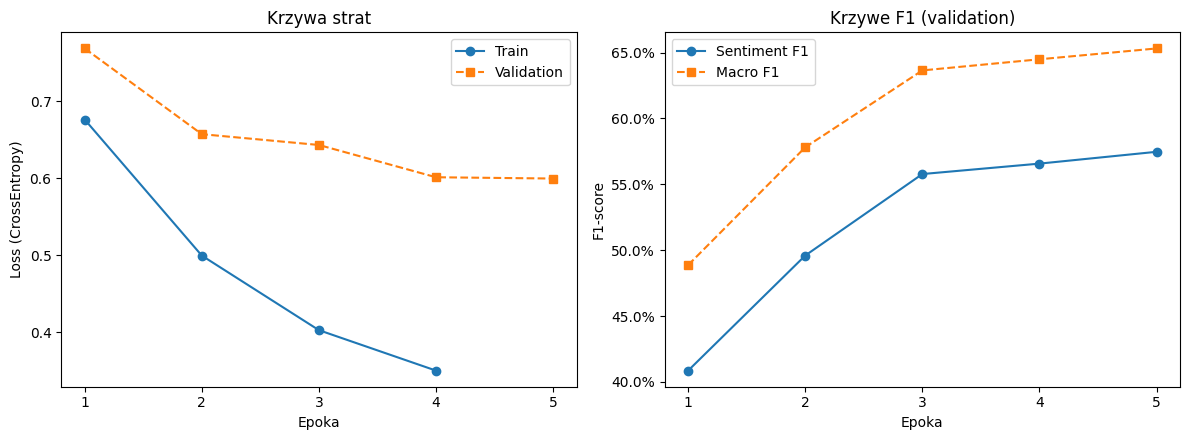

Najlepsza epoka (min eval_loss): 5 — eval_loss=0.5996, sentiment_f1=0.5747
Luka generalizacyjna (epoka 5): Δloss=+nan
→ Uwaga: możliwe przeuczenie


In [6]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import pandas as pd
import json

h = pd.DataFrame(history)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))

ax1.plot(h["epoch"], h["train_loss"], "o-", label="Train")
ax1.plot(h["epoch"], h["eval_loss"], "s--", label="Validation")
ax1.set_xlabel("Epoka")
ax1.set_ylabel("Loss (CrossEntropy)")
ax1.set_title("Krzywa strat")
ax1.legend()
ax1.set_xticks(h["epoch"])

ax2.plot(h["epoch"], h["eval_sentiment_f1"], "o-", label="Sentiment F1")
ax2.plot(h["epoch"], h["eval_macro_f1"], "s--", label="Macro F1")
ax2.set_xlabel("Epoka")
ax2.set_ylabel("F1-score")
ax2.set_title("Krzywe F1 (validation)")
ax2.legend()
ax2.set_xticks(h["epoch"])
ax2.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

plt.tight_layout()
plt.show()

gap_loss = h.iloc[-1]["train_loss"] - h.iloc[-1]["eval_loss"]
best_val = h.loc[h["eval_loss"].idxmin()]

print(f"Najlepsza epoka (min eval_loss): {int(best_val['epoch'])} — eval_loss={best_val['eval_loss']:.4f}, sentiment_f1={best_val['eval_sentiment_f1']:.4f}")
print(f"Luka generalizacyjna (epoka {int(h.iloc[-1]['epoch'])}): Δloss={gap_loss:+.4f}")
print(f"{'→ Brak oznak przeuczenia (eval_loss ≤ train_loss)' if gap_loss >= 0 else '→ Uwaga: możliwe przeuczenie'}")

In [7]:
os.makedirs(SAVE_DIR, exist_ok=True)

safe_name = MODEL_NAME.replace("/", "_")
save_path = os.path.join(SAVE_DIR, f"{safe_name}_absa.pt")

torch.save(
    {
        "model_state_dict": model.state_dict(),
        "base_model_name": MODEL_NAME,
    },
    save_path,
)
print(f"Model saved → {save_path}")

history_path = os.path.join(SAVE_DIR, f"{safe_name}_training_history.json")
with open(history_path, "w") as f:
    json.dump(history, f, indent=2)
print(f"Training history saved → {history_path}")

Model saved → saved_models/distilbert-base-uncased-finetuned-sst-2-english_absa.pt
Training history saved → saved_models/distilbert-base-uncased-finetuned-sst-2-english_training_history.json


---
## Inferencja/predykcja

In [8]:
from predictions.prediction_fine_tuned import FineTunedModel

model = FineTunedModel(aspects=TRAIN_ASPECTS,local_model_path="saved_models/distilbert-base-uncased-finetuned-sst-2-english_absa.pt")

Using device: mps


Loading weights: 100%|██████████| 100/100 [00:00<00:00, 8068.45it/s]


In [9]:
test_texts = [
    "This park is dirty and unsafe at night, the paths are broken.",
    "Beautiful museum with free entry and amazing historical exhibitions!",
]

for text in test_texts:
    results = model.predict(text)

    print(f"\n>>> {text}")
    active = {k: v for k, v in results.items() if v != "notmentioned"}
    print(f"  Active sentiments: {active if active else 'None'}")
    print(f"  Full predictions:  {results}")


>>> This park is dirty and unsafe at night, the paths are broken.
  Active sentiments: {'safety': 'negative', 'cleanliness': 'negative', 'infrastructure': 'negative', 'nature': 'negative', 'other': 'negative'}
  Full predictions:  {'safety': 'negative', 'cleanliness': 'negative', 'infrastructure': 'negative', 'nature': 'negative', 'attractions': 'notmentioned', 'heritage': 'notmentioned', 'costs': 'notmentioned', 'other': 'negative'}

>>> Beautiful museum with free entry and amazing historical exhibitions!
  Active sentiments: {'nature': 'positive', 'attractions': 'positive', 'heritage': 'positive', 'other': 'positive'}
  Full predictions:  {'safety': 'notmentioned', 'cleanliness': 'notmentioned', 'infrastructure': 'notmentioned', 'nature': 'positive', 'attractions': 'positive', 'heritage': 'positive', 'costs': 'notmentioned', 'other': 'positive'}
